# 5.7 Implementing Linear Regression using Python

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## Importing (Reading) Datasets

In [2]:
df = pd.read_csv('../data/Salary_Data.csv')

## Exploring Dataset

In [3]:
df.head()

,YearsExperience,Salary
0,8.4,136508.0
1,5.2,85368.0
2,9.2,132839.0
3,7.7,113331.0
4,2.0,52080.0


In [4]:
df.shape

(30, 2)

## Checking for any null values in dataset

In [5]:
df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

## Cleaning null values

In [6]:
df = df.dropna()

## Assigning Dependent and Independent variables

In [7]:
x = df[['YearsExperience']]
y = df['Salary']

## Splitting the dataset into Training and Testing Dataset

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(f"Training set size: {x_train.shape[0]} rows")
print(f"Test set size: {x_test.shape[0]} rows")

Training set size: 24 rows
Test set size: 6 rows


## Fitting the Model (Linear Regression)

In [9]:
mdl = LinearRegression()
mdl.fit(x_train, y_train)
print(f"Intercept: {mdl.intercept_:.2f}")
print(f"Coefficient: {mdl.coef_[0]:.2f}")

Intercept: 24743.70
Coefficient: 12095.67


## Evaluation Metrics

In [10]:
y_pred = mdl.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MSE: {mse:.2f}")
print(f"R2: {r2:.2f}")

MSE: 15150464.97
R2: 0.99


## Plot for Training and Testing dataset

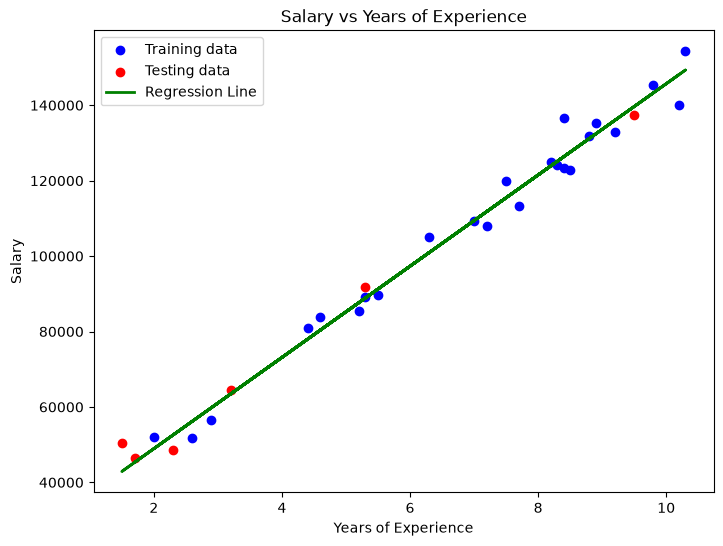

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(x_train, y_train, color='blue', label='Training data')
plt.scatter(x_test, y_test, color='red', label='Testing data')
plt.plot(x, mdl.predict(x), color='green', linewidth=2, label='Regression Line')
plt.title('Salary vs Years of Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.show()